In [ ]:
import warnings
warnings.filterwarnings("ignore")
import math

# ── Data Handling ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine Learning ───────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ── Advanced ML Model ──────────────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── Deep Learning ──────────────────────────────────────────────────────────────
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


In [ ]:
df = pd.read_csv("../data/cleaned_data.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2993, 25)


,baby_id,name,gender,gestational_age_weeks,birth_weight_kg,birth_length_cm,birth_head_circumference_cm,date,age_days,weight_kg,...,oxygen_saturation,feeding_type,feeding_frequency_per_day,urine_output_count,stool_count,jaundice_level_mg_dl,apgar_score,immunizations_done,reflexes_normal,risk_level
0,B001,Sara,Female,40.2,3.3,50.0,31.9,2024-12-10,1,3.28,...,98,Formula,11,9,0,4.2,7.0,Yes,Yes,At Risk
1,B001,Sara,Female,40.2,3.3,50.0,31.9,2024-12-11,2,3.35,...,99,Formula,11,5,2,10.6,8.4,No,No,At Risk
2,B001,Sara,Female,40.2,3.3,50.0,31.9,2024-12-12,3,3.35,...,97,Breastfeeding,7,6,5,9.8,8.4,No,No,Healthy
3,B001,Sara,Female,40.2,3.3,50.0,31.9,2024-12-13,4,3.48,...,97,Mixed,11,8,4,8.1,8.4,No,Yes,Healthy
4,B001,Sara,Female,40.2,3.3,50.0,31.9,2024-12-14,5,3.50,...,96,Breastfeeding,11,7,1,11.6,8.4,No,Yes,At Risk


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2993 entries, 0 to 2992
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   baby_id                      2993 non-null   object 
 1   name                         2993 non-null   object 
 2   gender                       2993 non-null   object 
 3   gestational_age_weeks        2993 non-null   float64
 4   birth_weight_kg              2993 non-null   float64
 5   birth_length_cm              2993 non-null   float64
 6   birth_head_circumference_cm  2993 non-null   float64
 7   date                         2993 non-null   object 
 8   age_days                     2993 non-null   int64  
 9   weight_kg                    2993 non-null   float64
 10  length_cm                    2993 non-null   float64
 11  head_circumference_cm        2993 non-null   float64
 12  temperature_c                2993 non-null   float64
 13  heart_rate_bpm    

In [ ]:
df.describe()

,gestational_age_weeks,birth_weight_kg,birth_length_cm,birth_head_circumference_cm,age_days,weight_kg,length_cm,head_circumference_cm,temperature_c,heart_rate_bpm,respiratory_rate_bpm,oxygen_saturation,feeding_frequency_per_day,urine_output_count,stool_count,jaundice_level_mg_dl,apgar_score
count,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000,2993.000000
mean,38.878617,3.204688,49.724223,34.127030,15.507852,3.669689,50.505546,34.438223,37.002639,139.684263,39.427999,97.464751,9.451052,6.470765,2.445707,4.159338,8.400000
std,1.569741,0.561225,2.142884,1.487414,8.658557,0.621009,2.195692,1.502034,0.310742,10.134665,4.998420,1.035553,1.707083,1.701062,1.698677,2.856780,0.211627
min,35.400000,1.860000,45.100000,31.200000,1.000000,1.790000,45.000000,31.100000,35.800000,100.000000,23.000000,94.000000,7.000000,4.000000,0.000000,0.000000,7.000000
25%,37.800000,2.870000,48.400000,32.900000,8.000000,3.220000,49.100000,33.300000,36.800000,133.000000,36.000000,97.000000,8.000000,5.000000,1.000000,2.500000,8.400000
50%,38.800000,3.150000,49.500000,34.100000,16.000000,3.660000,50.400000,34.400000,37.000000,140.000000,39.000000,97.000000,9.000000,6.000000,2.000000,3.300000,8.400000
75%,40.100000,3.620000,51.000000,34.800000,23.000000,4.100000,51.800000,35.300000,37.200000,146.000000,43.000000,98.000000,11.000000,8.000000,4.000000,4.300000,8.400000
max,43.000000,4.470000,55.800000,38.100000,30.000000,5.410000,57.400000,38.700000,38.100000,173.000000,57.000000,100.000000,12.000000,9.000000,5.000000,15.000000,10.000000


In [ ]:
print("Columns:", df.columns.tolist())

Columns: ['baby_id', 'name', 'gender', 'gestational_age_weeks', 'birth_weight_kg', 'birth_length_cm', 'birth_head_circumference_cm', 'date', 'age_days', 'weight_kg', 'length_cm', 'head_circumference_cm', 'temperature_c', 'heart_rate_bpm', 'respiratory_rate_bpm', 'oxygen_saturation', 'feeding_type', 'feeding_frequency_per_day', 'urine_output_count', 'stool_count', 'jaundice_level_mg_dl', 'apgar_score', 'immunizations_done', 'reflexes_normal', 'risk_level']


In [ ]:
# ── Check for missing values ───────────────────────────────────────────────────
print ( "Missing values")
print ( df.isnull().sum())

Missing values
baby_id                        0
name                           0
gender                         0
gestational_age_weeks          0
birth_weight_kg                0
birth_length_cm                0
birth_head_circumference_cm    0
date                           0
age_days                       0
weight_kg                      0
length_cm                      0
head_circumference_cm          0
temperature_c                  0
heart_rate_bpm                 0
respiratory_rate_bpm           0
oxygen_saturation              0
feeding_type                   0
feeding_frequency_per_day      0
urine_output_count             0
stool_count                    0
jaundice_level_mg_dl           0
apgar_score                    0
immunizations_done             0
reflexes_normal                0
risk_level                     0
dtype: int64


In [ ]:
# ── Check for duplicates ───────────────────────────────────────────────────────
print("Duplicated values")
print( df.duplicated().sum())

Duplicated values
0


In [ ]:
# ── Verify data types ─────────────────────────────────────────────────────────
print("Data types:")
print(df.dtypes)

Data types:
baby_id                         object
name                            object
gender                          object
gestational_age_weeks          float64
birth_weight_kg                float64
birth_length_cm                float64
birth_head_circumference_cm    float64
date                            object
age_days                         int64
weight_kg                      float64
length_cm                      float64
head_circumference_cm          float64
temperature_c                  float64
heart_rate_bpm                   int64
respiratory_rate_bpm             int64
oxygen_saturation                int64
feeding_type                    object
feeding_frequency_per_day        int64
urine_output_count               int64
stool_count                      int64
jaundice_level_mg_dl           float64
apgar_score                    float64
immunizations_done              object
reflexes_normal                 object
risk_level                      object
dtype: object

Class Distribution:
            Count  Percentage (%)
risk_level                       
0            2597           86.77
1             396           13.23


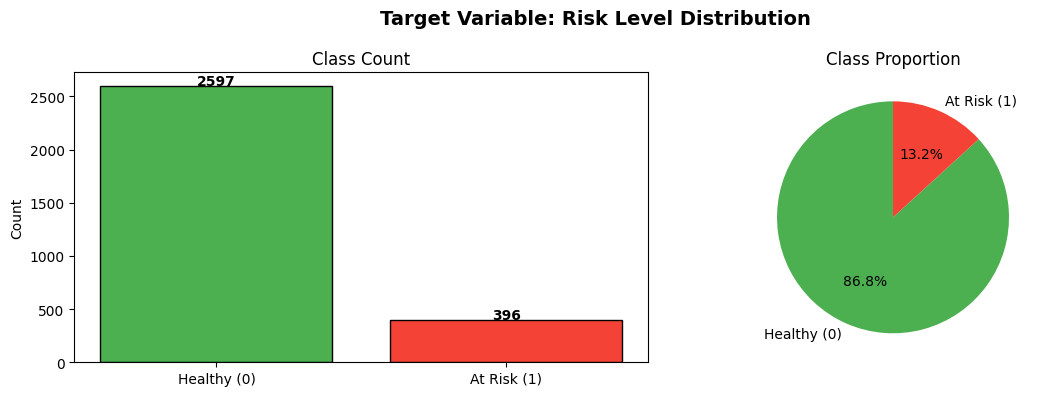

In [ ]:
# ── Encode target for analysis ─────────────────────────────────────────────────
if df['risk_level'].dtype == object:
    df['risk_level'] = df['risk_level'].map({'Healthy': 0, 'At Risk': 1})

counts = df['risk_level'].value_counts()
pct    = df['risk_level'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(pd.DataFrame({'Count': counts, 'Percentage (%)': pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Healthy (0)', 'At Risk (1)'], counts, color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_title("Class Count")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].pie(counts, labels=['Healthy (0)', 'At Risk (1)'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90)
axes[1].set_title("Class Proportion")

plt.suptitle("Target Variable: Risk Level Distribution", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Numerical features: ['gestational_age_weeks', 'birth_weight_kg', 'birth_length_cm', 'birth_head_circumference_cm', 'age_days', 'weight_kg', 'length_cm', 'head_circumference_cm', 'temperature_c', 'heart_rate_bpm', 'respiratory_rate_bpm', 'oxygen_saturation', 'feeding_frequency_per_day', 'urine_output_count', 'stool_count', 'jaundice_level_mg_dl', 'apgar_score']


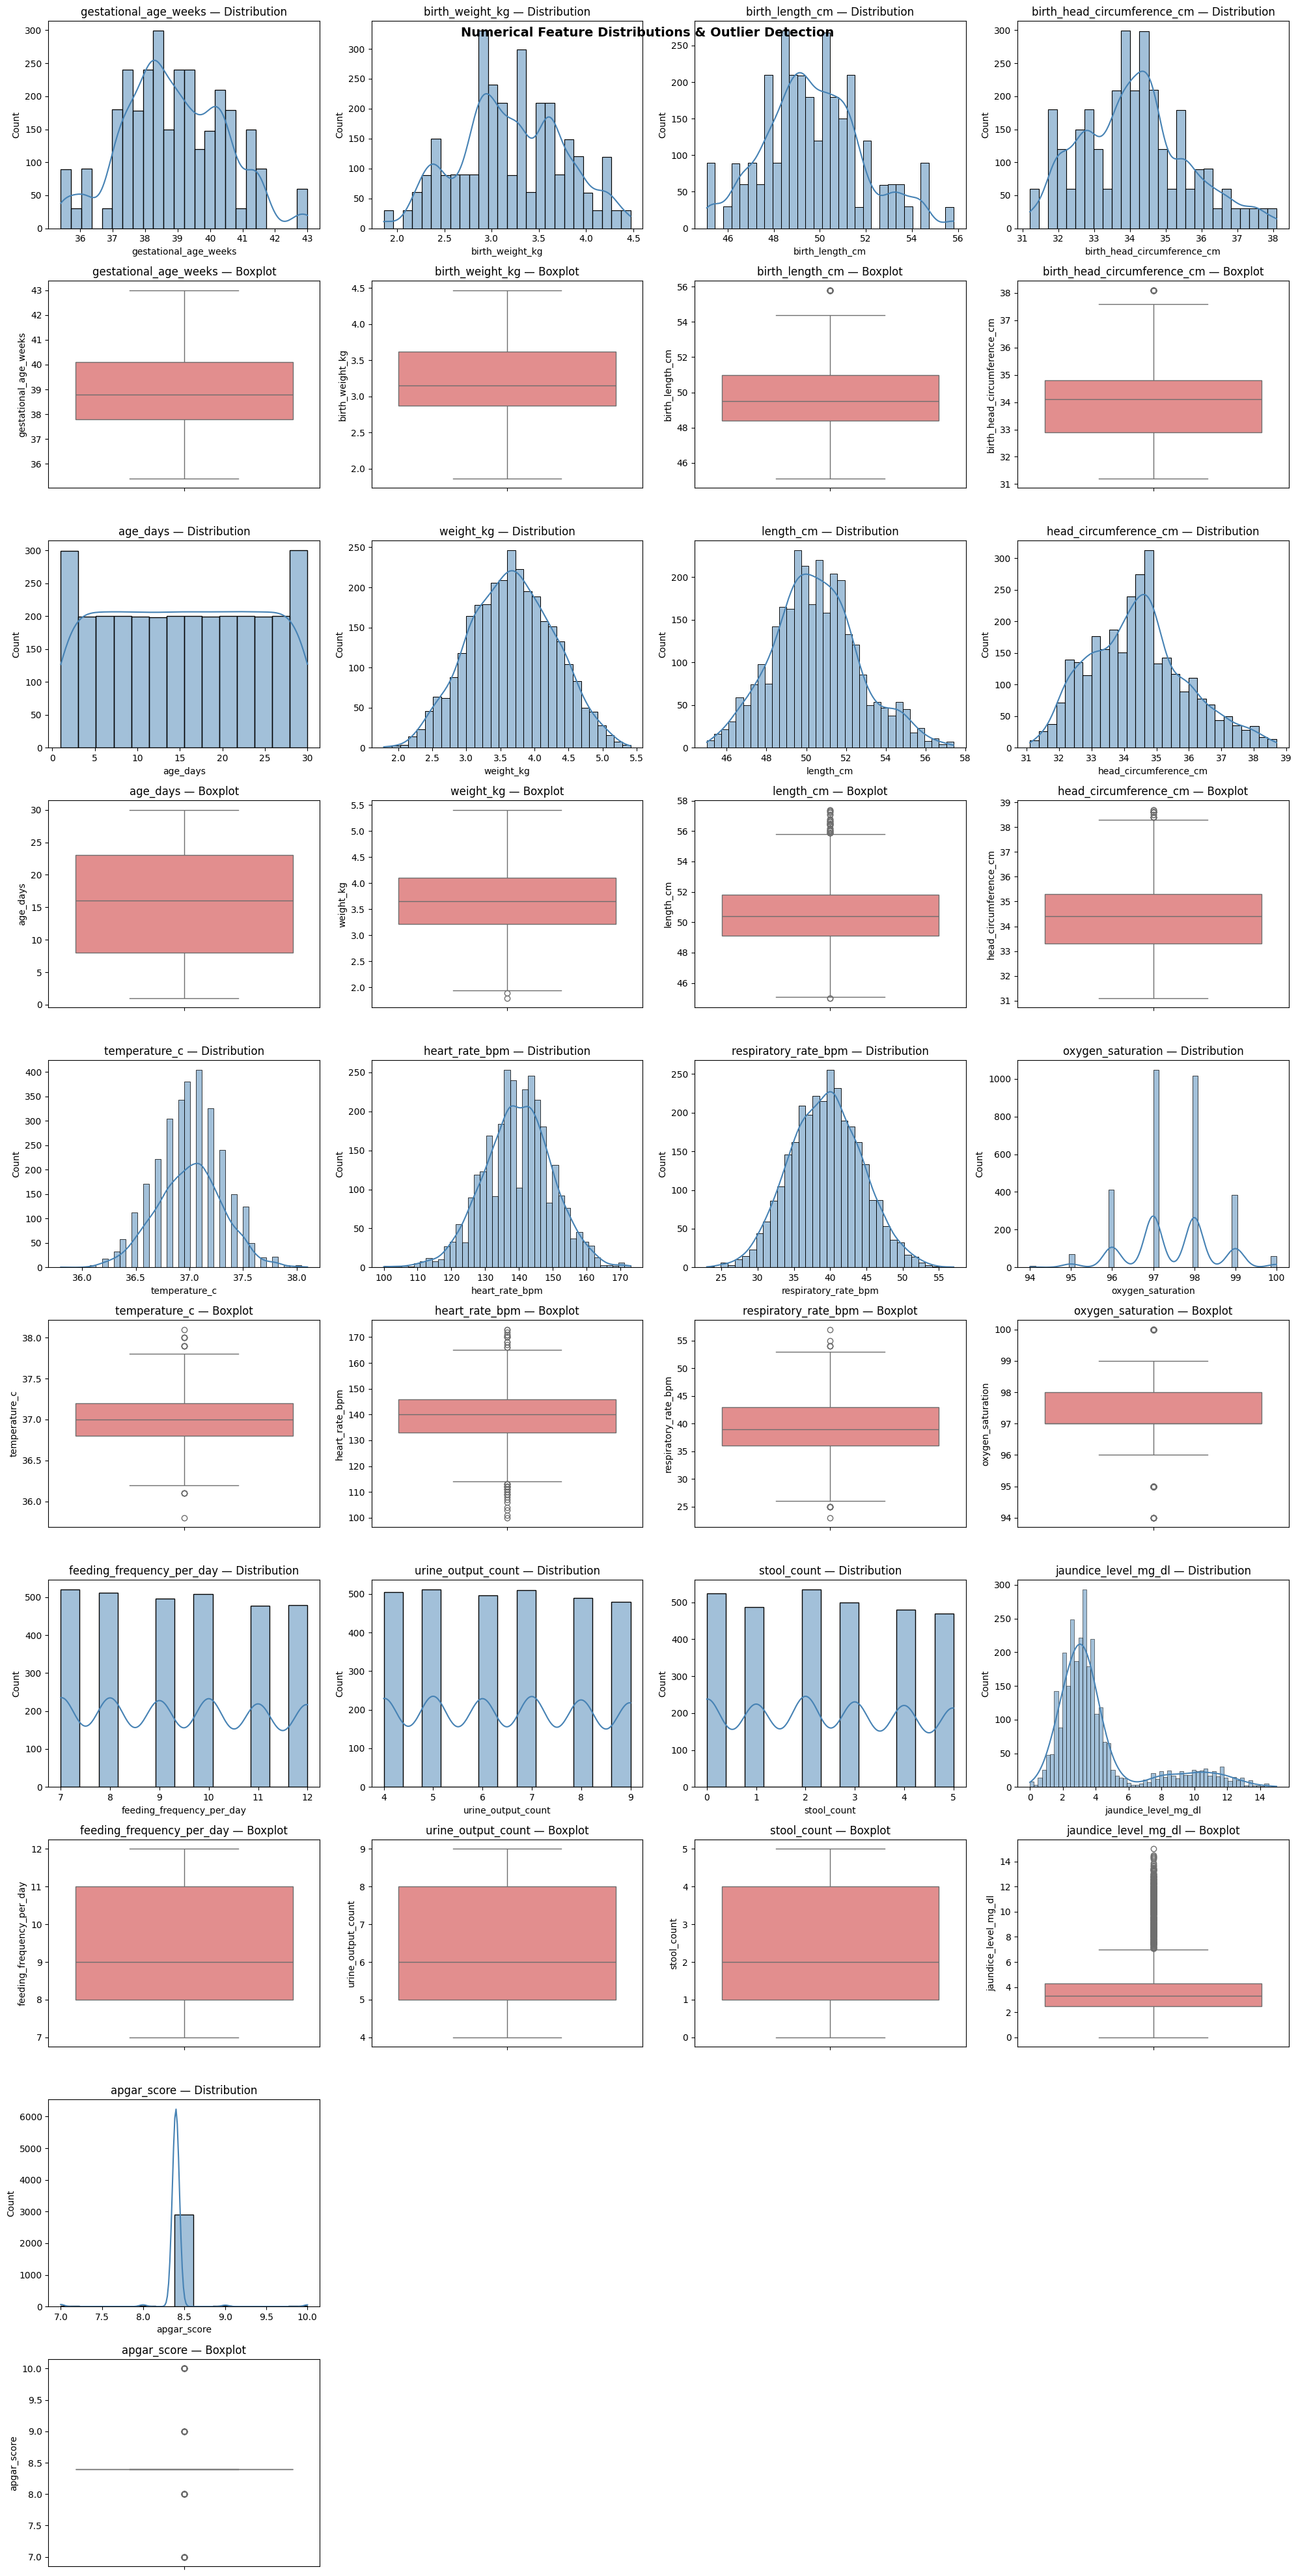

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns.drop('risk_level', errors='ignore').tolist()

n = len(numeric_cols)
cols = 4 
var_rows = math.ceil(n / cols)

# 2 subplot rows for every feature row (histogram, boxplot)
fig, axes = plt.subplots(var_rows * 2, cols, figsize=(5 * cols, 4 * var_rows * 2))
if var_rows * 2 == 1:
    axes = axes.reshape(1, -1)
elif cols == 1:
    axes = axes.reshape(-1, 1)

for i, col in enumerate(numeric_cols):
    # Determine the feature's row and column position in the grid
    r = i // cols
    c = i % cols
    hist_row = r * 2
    box_row = r * 2 + 1
    
    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[hist_row, c], color='steelblue')
    axes[hist_row, c].set_title(f"{col} — Distribution")
    axes[hist_row, c].set_xlabel(col)
    
    # Boxplot 
    sns.boxplot(y=df[col], ax=axes[box_row, c], color='lightcoral')
    axes[box_row, c].set_title(f"{col} — Boxplot")

# Clean up empty subplots if the number of features isn't a perfect multiple of 4
for j in range(n, var_rows * cols):
    r = j // cols
    c = j % cols
    fig.delaxes(axes[r * 2, c])
    fig.delaxes(axes[r * 2 + 1, c])

plt.suptitle("Numerical Feature Distributions & Outlier Detection", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Plotting Categorical features: ['gender', 'feeding_type', 'immunizations_done', 'reflexes_normal']


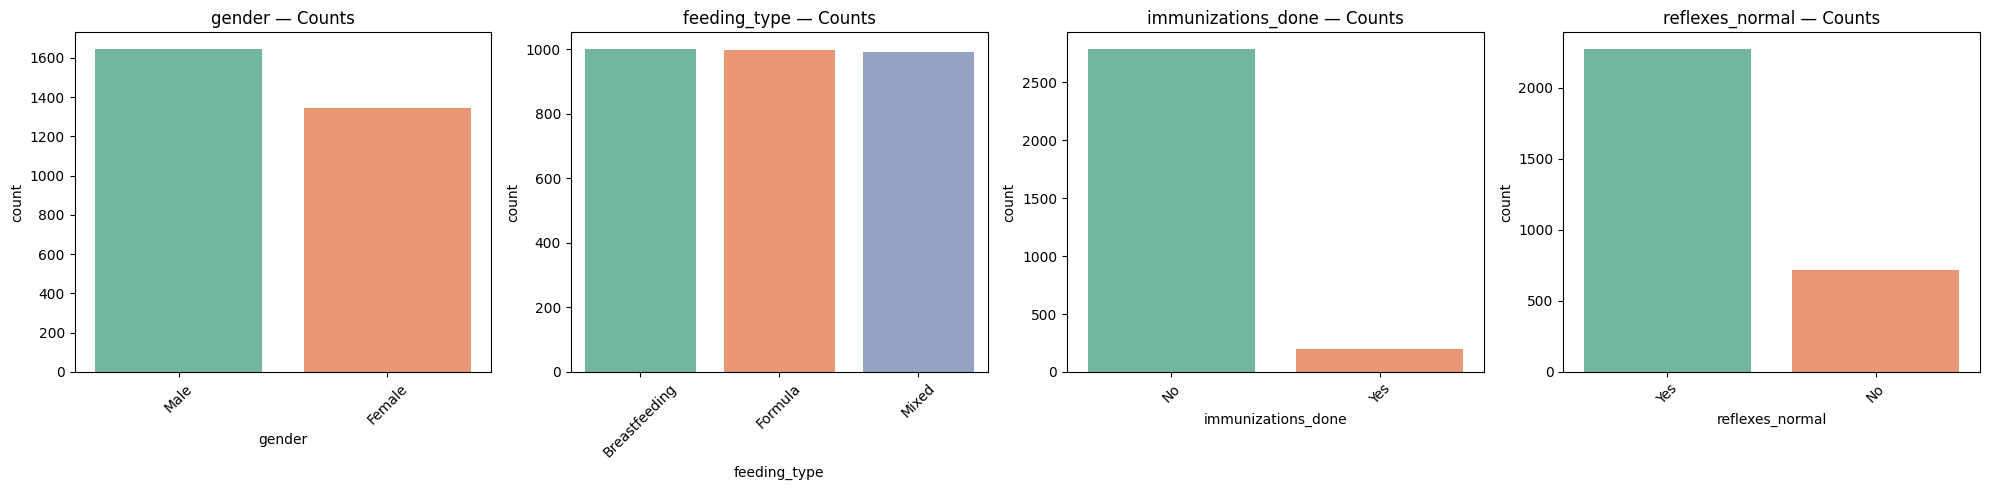

In [ ]:
# Filter: Remove constants and more than 15 unique categories
cat_cols = [
    col for col in df.select_dtypes(include='object').columns 
    if 1 < df[col].nunique() <= 15
]

if cat_cols:
    n = len(cat_cols)
    cols = 4 
    rows = math.ceil(n / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows), squeeze=False)
    
    for i, col in enumerate(cat_cols):
        r, c = i // cols, i % cols
        order = df[col].value_counts().index
        sns.countplot(x=col, data=df, order=order, ax=axes[r, c], palette='Set2')
        axes[r, c].set_title(f"{col} — Counts")
        axes[r, c].tick_params(axis='x', rotation=45)

        
    plt.tight_layout()
    plt.show()
else:
    print("No meaningful categorical features found (too many categories or constant).")

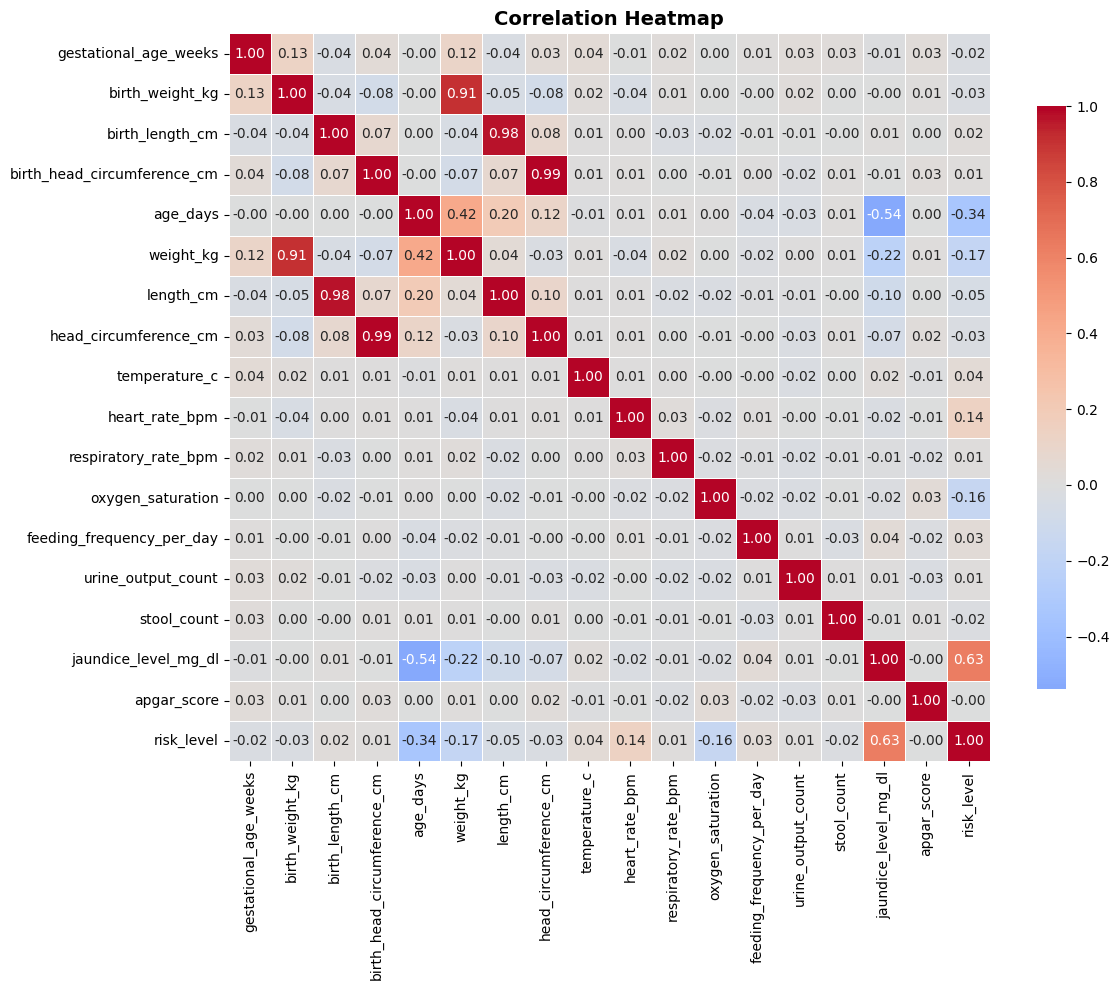


Top feature correlations with risk_level:
jaundice_level_mg_dl           0.628877
age_days                       0.337400
weight_kg                      0.171642
oxygen_saturation              0.160994
heart_rate_bpm                 0.141110
length_cm                      0.049677
temperature_c                  0.041117
feeding_frequency_per_day      0.034308
birth_weight_kg                0.032205
head_circumference_cm          0.027667
gestational_age_weeks          0.024272
birth_length_cm                0.018413
stool_count                    0.015386
respiratory_rate_bpm           0.011743
birth_head_circumference_cm    0.010341
urine_output_count             0.010191
apgar_score                    0.001864
Name: risk_level, dtype: float64


In [81]:
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()


sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",linewidths=0.5,center=0,cbar_kws={"shrink": 0.8})

plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target
if 'risk_level' in corr.columns:
    print("\nTop feature correlations with risk_level:")
    print(corr['risk_level'].drop('risk_level', errors='ignore').abs().sort_values(ascending=False))

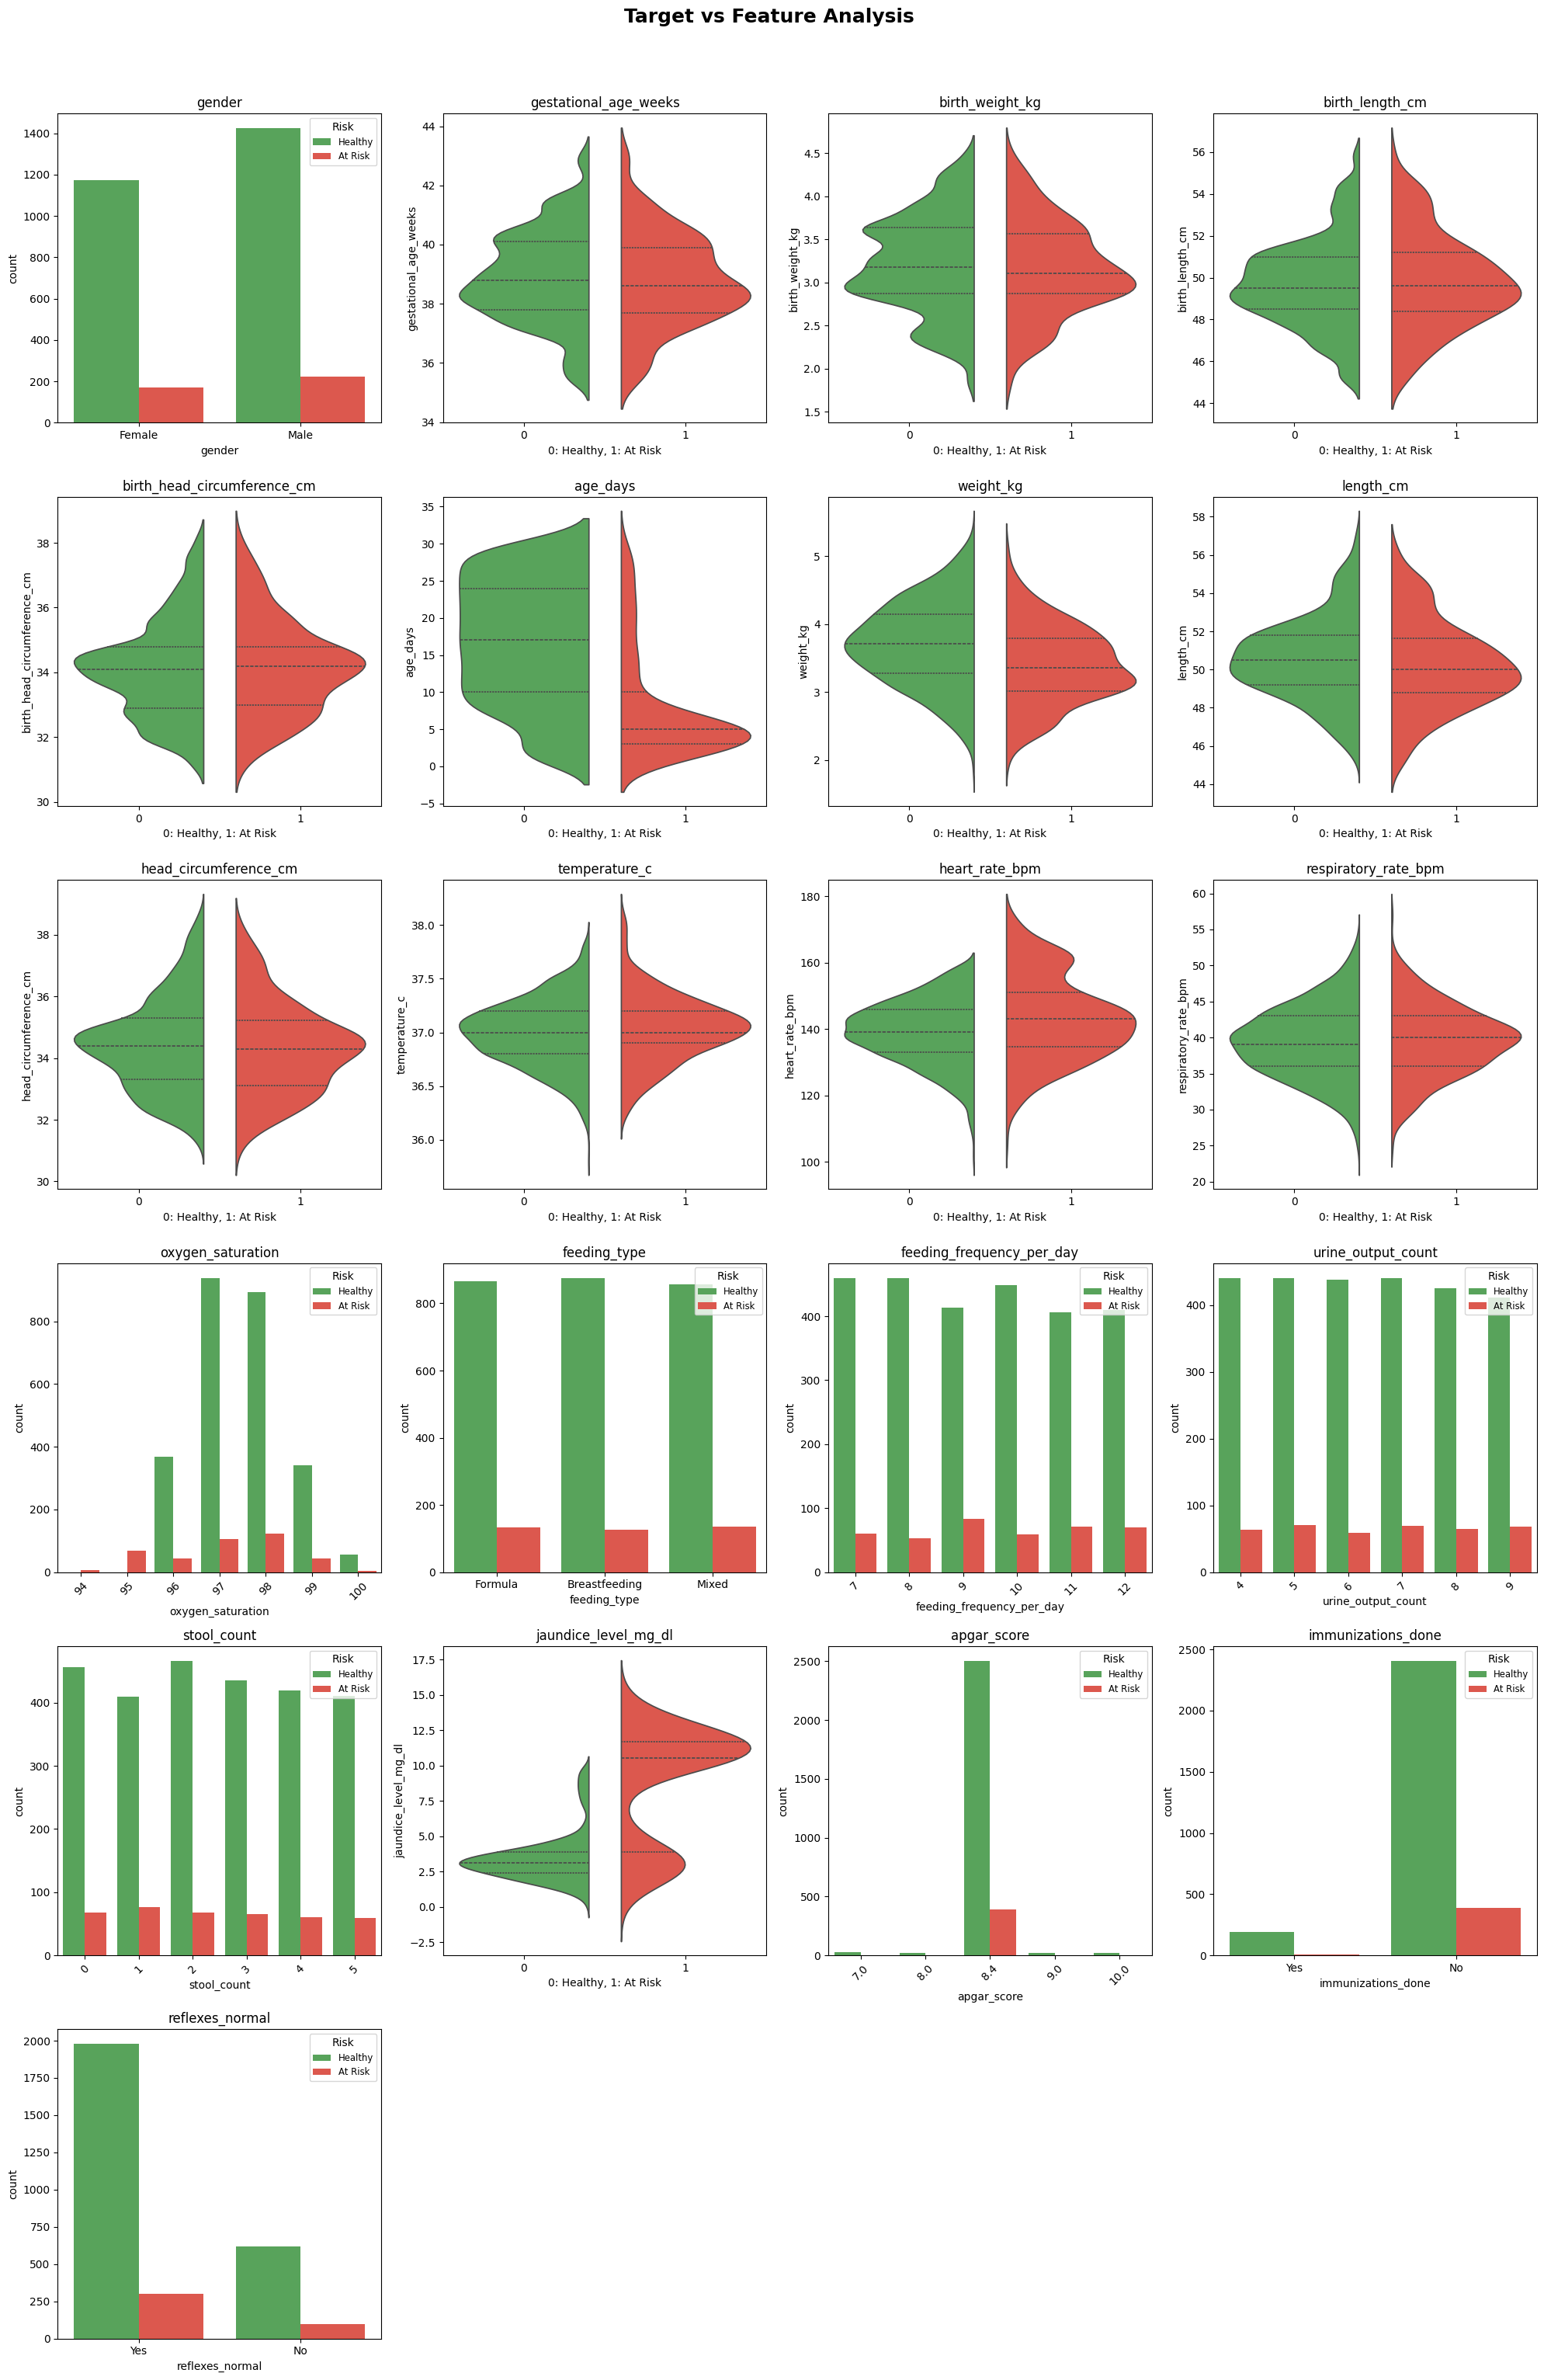

In [ ]:
# 1. Filter out IDs, Names, Dates, and the Target
ignore_keywords = ['date', 'name', 'baby_id']
all_features = [
    col for col in df.columns 
    if col.lower() != 'risk_level' 
    and not any(key in col.lower() for key in ignore_keywords)
]

color_map = {0: '#4CAF50', 1: '#F44336'}
n = len(all_features)
cols = 4 
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows), squeeze=False)

for i, col in enumerate(all_features):
    r, c = i // cols, i % cols
    unique_count = df[col].nunique()
    
    if unique_count <= 10 :
        # Countplot
        sns.countplot(x=col, hue='risk_level', data=df, palette=color_map, ax=axes[r, c])
        axes[r, c].set_title(col)
        axes[r, c].legend(title='Risk', labels=['Healthy', 'At Risk'], fontsize='small')
        
        if unique_count > 3:
            axes[r, c].tick_params(axis='x', rotation=45)
    else:
        # Violin Plot
        sns.violinplot(x='risk_level', y=col, data=df, palette=color_map, hue='risk_level', inner="quart", split=True, ax=axes[r, c], legend=False)
        axes[r, c].set_title(col)
        axes[r, c].set_xlabel("0: Healthy, 1: At Risk")

# 2. Clean up empty subplots
for j in range(n, rows * cols):
    fig.delaxes(axes[j // cols, j % cols])

plt.suptitle("Target vs Feature Analysis ", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()